In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mlflow
import os
import tempfile

mlflow.set_registry_uri('https://localhost:5000')
mlflow.set_experiment('case')
mlflow.sklearn.autolog()

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay, roc_curve
from IPython.display import display

2025/12/12 02:48:46 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/12 02:48:46 INFO mlflow.store.db.utils: Updating database tables
2025/12/12 02:48:46 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/12 02:48:46 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2025/12/12 02:48:47 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2025/12/12 02:48:47 INFO alembic.runtime.migration: Will assume non-transactional DDL.


Carregando o dataset de modelagem gerado no Notebook 2

In [ ]:
df = pd.read_csv('../data/df_final.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10738 entries, 0 to 10737
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      10738 non-null  int64  
 1   safra   10738 non-null  int64  
 2   y       10738 non-null  int64  
 3   VAR_6   10647 non-null  float64
 4   VAR_20  10738 non-null  int64  
 5   VAR_19  10677 non-null  float64
 6   VAR_25  10677 non-null  float64
 7   VAR_44  10677 non-null  float64
 8   VAR_9   10738 non-null  float64
 9   VAR_57  10738 non-null  int64  
 10  VAR_33  10677 non-null  float64
dtypes: float64(6), int64(5)
memory usage: 922.9 KB


Alterando o tipo de variável safra usado para geração do split temporal

In [ ]:
df['safra'] = pd.to_datetime(df['safra'].astype(str), format="%Y%m")

Separa-se o periodo de treino entre janeiro e setembro, teste para outubro e novembro e validação fora do tempo, o período de dezembro de 2014

In [ ]:
train = df.loc[df['safra'] < pd.Timestamp('2014-10-01')]
test = df.loc[(df['safra'] >= pd.Timestamp('2014-10-01')) & (df['safra'] < pd.Timestamp('2014-12-01'))]
val = df.loc[df['safra'] == pd.Timestamp('2014-12-01')]

Definindo o dataset com as variáveis explicativas, excluindo as chaves

In [ ]:
x_train = train.drop(['y', 'id', 'safra'], axis=1)
x_test =  test.drop(['y', 'id', 'safra'], axis=1)
x_val = val.drop(['y', 'id', 'safra'], axis=1)

e a target (y)

In [ ]:
y_train = train['y']
y_test =  test['y']
y_val = val['y']

Definimos um baseline uma Árvore de Decisão com profundidade maxima igual a 5. Esse baseline tem Roc Auc igual a 0.7
As variávies com maior ganho informacional são (6,20, 57 e 9).

O KS do baseline de referencia é igual a  15%, sugerindo um corte no percentil 25.

2025/12/12 01:27:39 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


AUC Baseline: 0.6875040684428325


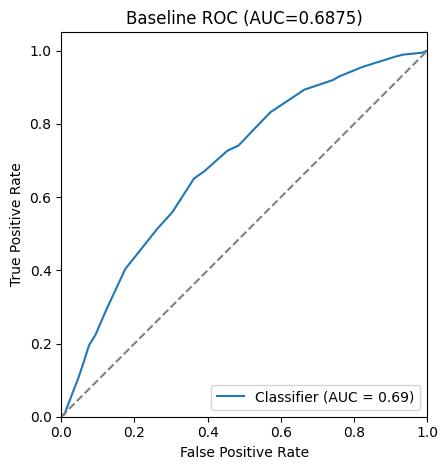

Feature importances:


,importance
VAR_6,0.383470
VAR_20,0.257860
VAR_57,0.179581
VAR_9,0.136743
VAR_25,0.034680
VAR_44,0.007665
VAR_19,0.000000
VAR_33,0.000000


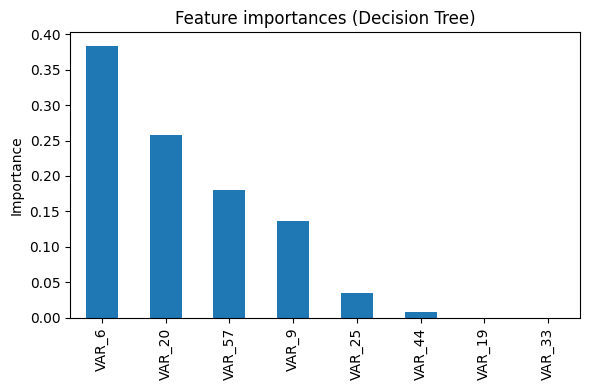

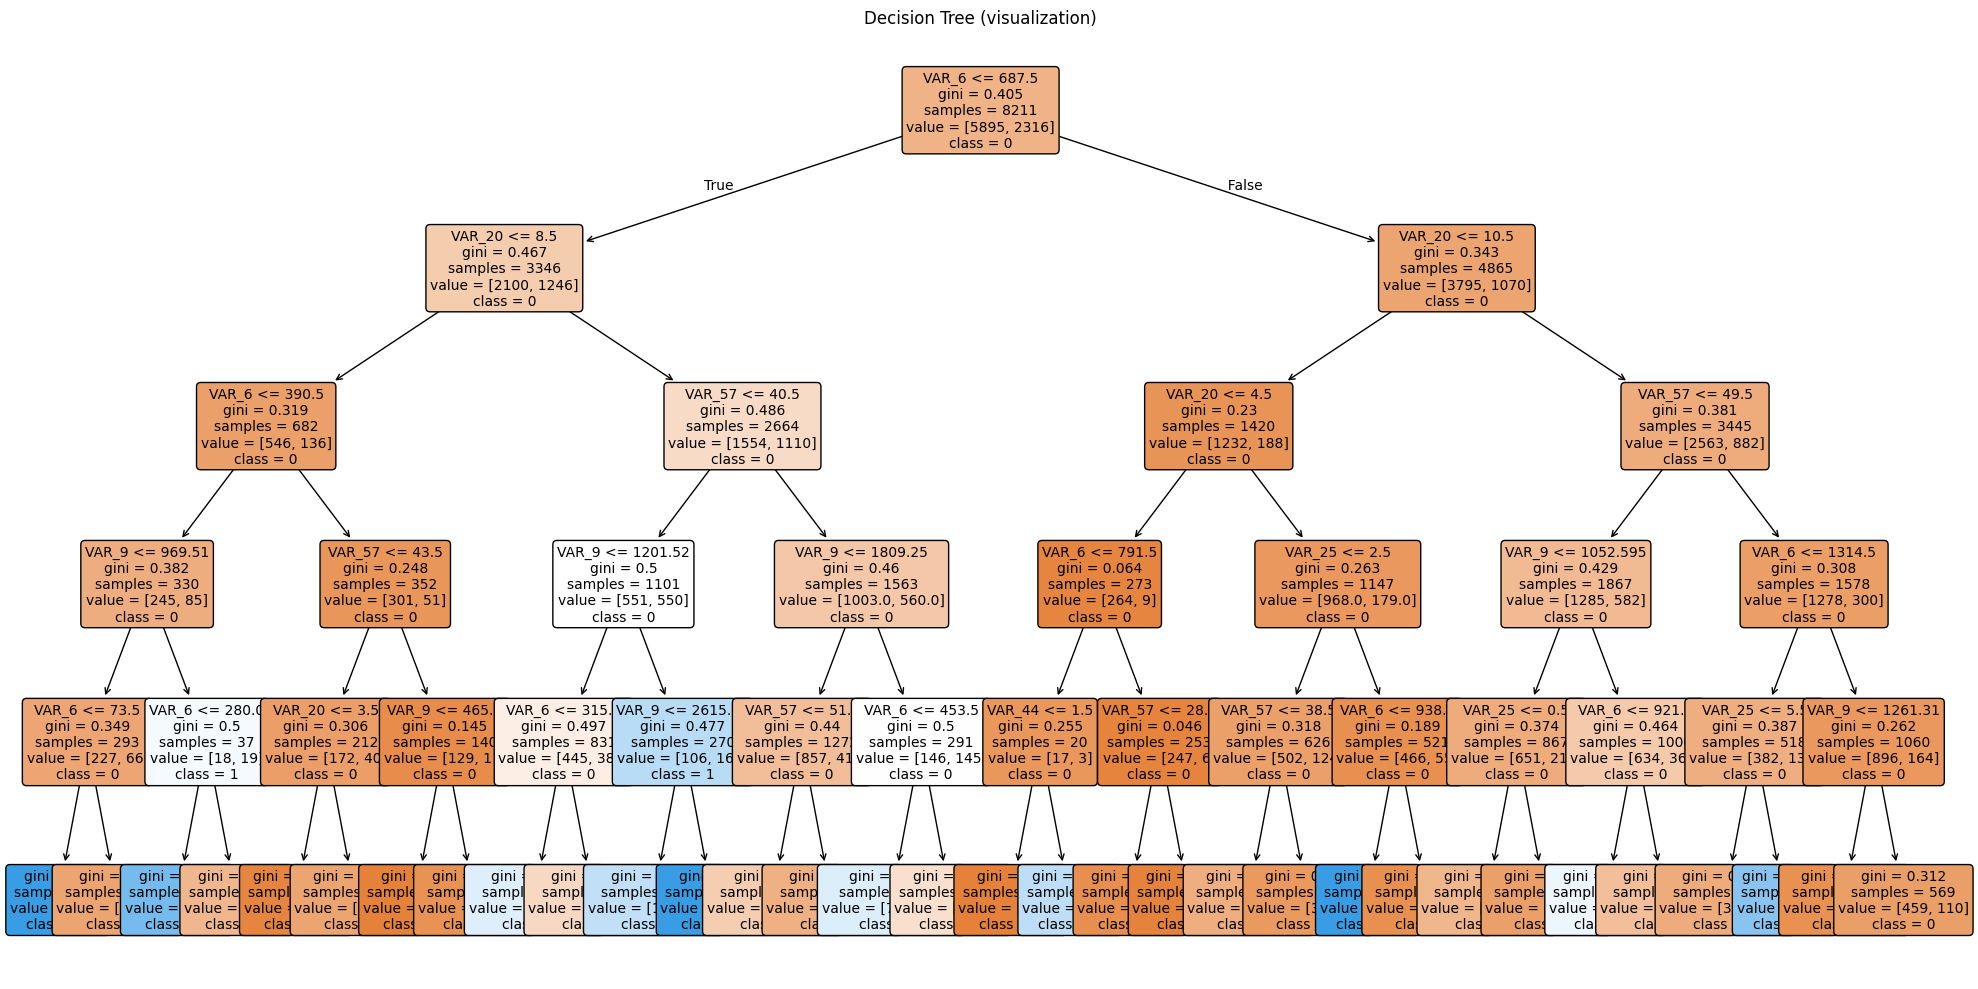

In [ ]:
from sklearn import tree as sktree


baseline = DecisionTreeClassifier(random_state=42, max_depth=5)

with mlflow.start_run():

    mlflow.log_param("baseline", "decision_tree")
    mlflow.log_param("n_vars", x_train.shape[1])

    baseline.fit(x_train, y_train)
    pred = baseline.predict_proba(x_test)[:,1]

    auc = roc_auc_score(y_test, pred)
    mlflow.log_metric("auc", auc)

    print("AUC Baseline:", auc)
    
    # close any existing figures so only this one is shown
    plt.close('all')

    fig, ax = plt.subplots()
    fpr, tpr, thresholds = roc_curve(y_test, pred)
    # plot ROC curve on the new axes
    RocCurveDisplay.from_predictions(y_test, pred, ax=ax)
    # plot diagonal "no-skill" line
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax.set_title(f'Baseline ROC (AUC={auc:.4f})')
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    plt.tight_layout()

    tmp = tempfile.NamedTemporaryFile(suffix='.png', delete=False)
    tmp.close()
    fig.savefig(tmp.name)
    mlflow.log_artifact(tmp.name, artifact_path='roc')

    # display only this figure in the notebook
    display(fig)
    # feature importances (as dataframe) and bar plot
    fi = pd.Series(baseline.feature_importances_, index=x_train.columns).sort_values(ascending=False)
    print("Feature importances:")
    display(fi.to_frame('importance'))

    plt.close('all')
    fig_fi, ax = plt.subplots(figsize=(6, 4))
    fi.plot(kind='bar', ax=ax)
    ax.set_title('Feature importances (Decision Tree)')
    ax.set_ylabel('Importance')
    plt.tight_layout()

    tmp_fi = tempfile.NamedTemporaryFile(suffix='.png', delete=False)
    tmp_fi.close()
    fig_fi.savefig(tmp_fi.name)
    mlflow.log_artifact(tmp_fi.name, artifact_path='feature_importance')
    display(fig_fi)
    os.remove(tmp_fi.name)
    plt.close(fig_fi)

    # graphical display of the tree

    plt.close('all')
    fig_tree, ax = plt.subplots(figsize=(20, 10))
    sktree.plot_tree(
        baseline,
        feature_names=x_train.columns,
        class_names=[str(c) for c in baseline.classes_],
        filled=True,
        rounded=True,
        fontsize=10,
        ax=ax
    )
    ax.set_title('Decision Tree (visualization)')
    plt.tight_layout()

    tmp_tree = tempfile.NamedTemporaryFile(suffix='.png', delete=False)
    tmp_tree.close()
    fig_tree.savefig(tmp_tree.name)
    mlflow.log_artifact(tmp_tree.name, artifact_path='tree')
    display(fig_tree)
    os.remove(tmp_tree.name)
    plt.close(fig_tree)
    os.remove(tmp.name)
    plt.close(fig)






Define-se também a função abaixo para cálculo do KS para estimar a qualidade de separação entre as classes. O percentil 26 indica  a melhor separação entre classes usando apenas o corte seco.

In [ ]:
def ks_metrics (y_val: pd.Series, score:np.ndarray):
    bad = y_val.rename('BAD')
    good = (1-y_val).rename('GOOD')
    score = pd.Series(score).rename('SCORE')
    
    ks_table = pd.concat([score, good, bad], axis=1)
    ks_table['BINS'] = pd.qcut(ks_table['SCORE'],10, duplicates='drop')
    ks_table = ks_table.groupby(['BINS'], observed=False)[['GOOD', 'BAD']].sum()

    ks_table['GOOD_ACCUM'] = ks_table['GOOD'].cumsum()
    ks_table['BAD_ACCUM'] = ks_table['BAD'].cumsum()
    ks_table['GOOD_ACCUM_DIST'] = round(ks_table['GOOD_ACCUM']   / ks_table['GOOD_ACCUM'].max() *100,2)
    ks_table['BAD_ACCUM_DIST'] = round(ks_table['BAD_ACCUM'] / ks_table['BAD_ACCUM'].max() * 100,2)
    ks_table['KS'] = np.abs(ks_table['BAD_ACCUM_DIST'] - ks_table['GOOD_ACCUM_DIST'])
    return ks_table

In [ ]:
with mlflow.start_run():

    mlflow.log_param("baseline", "decision_tree")
    mlflow.log_param("n_vars", x_train.shape[1])

    baseline.fit(x_train, y_train)
    pred = baseline.predict_proba(x_test)[:,1]

    ks = ks_metrics(y_test, pred)

    print(f"KS Baseline: {ks.KS.max()}")
    display(ks)

2025/12/12 01:27:56 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


KS Baseline: 15.049999999999997


,GOOD,BAD,GOOD_ACCUM,BAD_ACCUM,GOOD_ACCUM_DIST,BAD_ACCUM_DIST,KS
BINS,,,,,,,
"(-0.001, 0.104]",32.0,9.0,32.0,9.0,17.20,11.25,5.95
"(0.104, 0.116]",17.0,4.0,49.0,13.0,26.34,16.25,10.09
"(0.116, 0.193]",28.0,10.0,77.0,23.0,41.40,28.75,12.65
"(0.193, 0.217]",14.0,10.0,91.0,33.0,48.92,41.25,7.67
"(0.217, 0.256]",12.0,4.0,103.0,37.0,55.38,46.25,9.13
"(0.256, 0.275]",18.0,3.0,121.0,40.0,65.05,50.00,15.05
"(0.275, 0.329]",24.0,13.0,145.0,53.0,77.96,66.25,11.71
"(0.329, 0.378]",17.0,8.0,162.0,61.0,87.10,76.25,10.85
"(0.378, 0.524]",9.0,8.0,171.0,69.0,91.94,86.25,5.69


Testando um algoritmo com maior capacidade de generalização como Random Forest, temos uma pequena melhora na performance do modelo, com ROC AUC igual a 0.72 e KS de 16;3%

2025/12/12 01:28:05 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


AUC Baseline: 0.7185892965081137


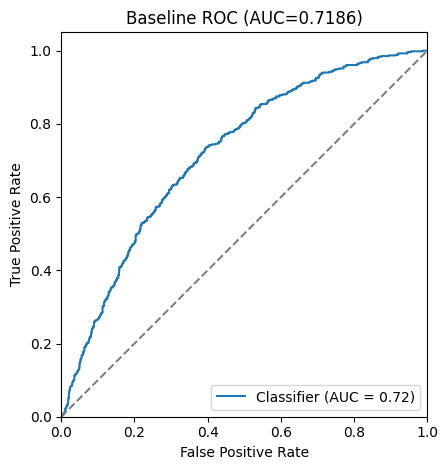

In [ ]:
model1 = RandomForestClassifier(random_state=42, max_depth=5)

with mlflow.start_run():

    mlflow.log_param("baseline", "decision_tree")
    mlflow.log_param("n_vars", x_train.shape[1])

    model1.fit(x_train, y_train)
    pred = model1.predict_proba(x_test)[:,1]

    auc = roc_auc_score(y_test, pred)
    mlflow.log_metric("auc", auc)

    print("AUC Baseline:", auc)
    
    # close any existing figures so only this one is shown
    plt.close('all')

    fig, ax = plt.subplots()
    fpr, tpr, thresholds = roc_curve(y_test, pred)
    # plot ROC curve on the new axes
    RocCurveDisplay.from_predictions(y_test, pred, ax=ax)
    # plot diagonal "no-skill" line
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax.set_title(f'Baseline ROC (AUC={auc:.4f})')
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    plt.tight_layout()

    tmp = tempfile.NamedTemporaryFile(suffix='.png', delete=False)
    tmp.close()
    fig.savefig(tmp.name)
    mlflow.log_artifact(tmp.name, artifact_path='roc')

    # display only this figure in the notebook
    display(fig)

    os.remove(tmp.name)
    plt.close(fig)

In [ ]:
with mlflow.start_run():

    mlflow.log_param("baseline", "decision_tree")
    mlflow.log_param("n_vars", x_train.shape[1])

    model1.fit(x_train, y_train)
    pred = model1.predict_proba(x_test)[:,1]

    ks = ks_metrics(y_test, pred)

    print(f"KS Baseline: {ks.KS.max()}")
    display(ks)

2025/12/12 01:28:15 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


KS Baseline: 16.299999999999997


,GOOD,BAD,GOOD_ACCUM,BAD_ACCUM,GOOD_ACCUM_DIST,BAD_ACCUM_DIST,KS
BINS,,,,,,,
"(0.0457, 0.132]",26.0,6.0,26.0,6.0,13.98,7.50,6.48
"(0.132, 0.17]",24.0,11.0,50.0,17.0,26.88,21.25,5.63
"(0.17, 0.202]",21.0,6.0,71.0,23.0,38.17,28.75,9.42
"(0.202, 0.229]",11.0,2.0,82.0,25.0,44.09,31.25,12.84
"(0.229, 0.259]",22.0,10.0,104.0,35.0,55.91,43.75,12.16
"(0.259, 0.297]",17.0,4.0,121.0,39.0,65.05,48.75,16.30
"(0.297, 0.339]",15.0,15.0,136.0,54.0,73.12,67.50,5.62
"(0.339, 0.38]",18.0,7.0,154.0,61.0,82.80,76.25,6.55
"(0.38, 0.429]",15.0,12.0,169.0,73.0,90.86,91.25,0.39


testando a expansão de hiperparâmetros usando grid search em um curto espaço, não obtem-se melhora significativa comparado ao inicilamente testado (profundidade máxima =5 e restante de paramẽtros como default)

In [ ]:
from itertools import product
import tempfile
import os

# grid
max_depths = [3, 5, 7]
n_estimators = [100, 200, 400]
ccp_alphas = [0.0, 1e-1, 10]

# detect if RandomForestClassifier supports ccp_alpha
_rf = RandomForestClassifier(random_state=42)
supports_ccp = 'ccp_alpha' in _rf.get_params()

best_auc = -1.0
best_run_id = None
best_params = None
run_count = 0
total_runs = len(max_depths) * len(n_estimators) * (len(ccp_alphas) if supports_ccp else 1)

for md, n_est, ccp in (product(max_depths, n_estimators, ccp_alphas) if supports_ccp else product(max_depths, n_estimators)):
    run_count += 1
    params = {"max_depth": md, "n_estimators": n_est}
    if supports_ccp:
        params["ccp_alpha"] = ccp

    with mlflow.start_run(nested=True) as run:
        run_id = run.info.run_id
        mlflow.log_params(params)
        mlflow.set_tag("search", "grid")
        mlflow.set_tag("progress", f"{run_count}/{total_runs}")

        # instantiate model with params
        if supports_ccp:
            model = RandomForestClassifier(random_state=42, max_depth=md, n_estimators=n_est, ccp_alpha=ccp, n_jobs=-1)
        else:
            model = RandomForestClassifier(random_state=42, max_depth=md, n_estimators=n_est, n_jobs=-1)

        model.fit(x_train, y_train)
        pred_test = model.predict_proba(x_test)[:, 1]

        test_auc = roc_auc_score(y_test, pred_test)
        mlflow.log_metric("test_auc", test_auc)

        # log ROC plot artifact
        plt.close('all')
        fig, ax = plt.subplots()
        RocCurveDisplay.from_predictions(y_test, pred_test, ax=ax)
        ax.plot([0,1],[0,1], linestyle='--', color='gray')
        ax.set_title(f"test ROC (AUC={test_auc:.4f})")
        tmp = tempfile.NamedTemporaryFile(suffix='.png', delete=False)
        tmp.close()
        fig.savefig(tmp.name)
        mlflow.log_artifact(tmp.name, artifact_path="roc")
        os.remove(tmp.name)
        plt.close(fig)

        # explicitly log model artifact
        mlflow.sklearn.log_model(model, artifact_path="model")

        if test_auc > best_auc:
            best_auc = test_auc
            best_run_id = run_id
            best_params = params.copy()

        print(f"[{run_count}/{total_runs}] run_id={run_id} params={params} test_auc={test_auc:.4f}")

# summary and register best model
print("Best validation AUC:", best_auc)
print("Best params:", best_params)
print("Best run id:", best_run_id)

if best_run_id is not None:
    best_model_uri = f"runs:/{best_run_id}/model"
    model_name = "random_forest_tuned"

    try:
        mv = mlflow.register_model(best_model_uri, model_name)
        print(f"Registered model {model_name} version: {mv.version}")
    except Exception as e:
        print("Model registration failed:", e)

2025/12/12 01:28:42 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/12/12 01:28:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/12 01:29:12 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[1/27] run_id=ead66a9c11de4832867d664cc9e64cc8 params={'max_depth': 3, 'n_estimators': 100, 'ccp_alpha': 0.0} test_auc=0.7117


2025/12/12 01:29:43 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/12/12 01:29:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/12 01:29:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[2/27] run_id=119237e771f84942a03eeaf2e76d64b3 params={'max_depth': 3, 'n_estimators': 100, 'ccp_alpha': 0.1} test_auc=0.5000


2025/12/12 01:30:27 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/12/12 01:30:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/12 01:30:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


...

[25/27] run_id=035cc8f5633c45f4ae9227193a2c1737 params={'max_depth': 7, 'n_estimators': 400, 'ccp_alpha': 0.0} test_auc=0.7145


2025/12/12 01:36:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/12/12 01:36:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/12 01:36:33 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[26/27] run_id=3aaa37476ab445b0966773b0d072cffd params={'max_depth': 7, 'n_estimators': 400, 'ccp_alpha': 0.1} test_auc=0.5000


2025/12/12 01:36:39 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2025/12/12 01:36:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/12 01:36:48 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


[27/27] run_id=7f15bde21d6745e48fc5a7cba0856d48 params={'max_depth': 7, 'n_estimators': 400, 'ccp_alpha': 10} test_auc=0.5000
Best validation AUC: 0.7185892965081137
Best params: {'max_depth': 5, 'n_estimators': 100, 'ccp_alpha': 0.0}
Best run id: 553884cc8d7b4144a8b2dd128f6713ae
Model registration failed: API request to https://localhost:5000/api/2.0/mlflow/registered-models/create failed with exception HTTPSConnectionPool(host='localhost', port=5000): Max retries exceeded with url: /api/2.0/mlflow/registered-models/create (Caused by SSLError(SSLError(1, '[SSL: WRONG_VERSION_NUMBER] wrong version number (_ssl.c:1007)')))


Comparando a estabilidade do score nos datasets de treino e validação, vê-se que há um pequeno descasamento entre a distribuição dos scores, mais notadamente no dataset out-of-time, mas ainda em um limiar aceitável para uso iniicial.

PSI (train -> test):  0.014883
PSI (train -> val):   0.032354
PSI (test -> val):    0.030463
Logged PSI metrics and artifacts to mlflow run: 7b659b74792e4628953b3bb24901377b


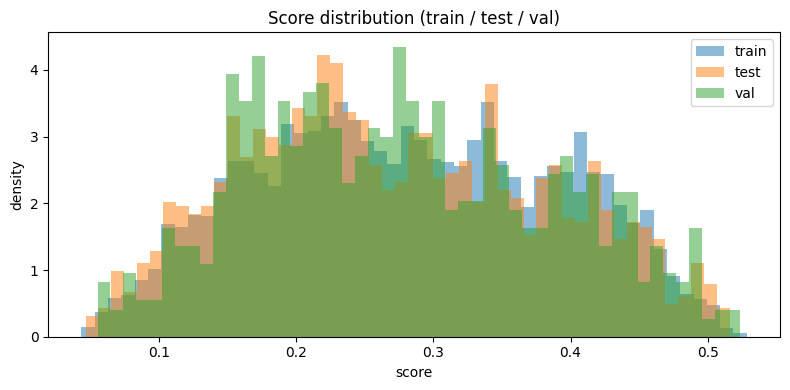

,bin_left,bin_right,exp_count,act_count,exp_pct,act_pct,psi
0,0.043705,0.139781,821,198,0.099988,0.113728,1.769138e-03
1,0.139781,0.179229,821,197,0.099988,0.113153,1.628520e-03
2,0.179229,0.214041,821,196,0.099988,0.112579,1.493394e-03
3,0.214041,0.243831,821,198,0.099988,0.113728,1.769138e-03
4,0.243831,0.279266,821,160,0.099988,0.091901,6.819785e-04
5,0.279266,0.314823,821,174,0.099988,0.099943,2.049133e-08
6,0.314823,0.347036,821,152,0.099988,0.087306,1.719984e-03
7,0.347036,0.390716,821,161,0.099988,0.092476,5.867331e-04
8,0.390716,0.429329,821,137,0.099988,0.078690,5.101308e-03
9,0.429329,0.528341,822,168,0.100110,0.096496,1.328314e-04


,bin_left,bin_right,exp_count,act_count,exp_pct,act_pct,psi
0,0.043705,0.139781,821,64,0.099988,0.081425,0.003812
1,0.139781,0.179229,821,108,0.099988,0.137405,0.011894
2,0.179229,0.214041,821,88,0.099988,0.111959,0.001354
3,0.214041,0.243831,821,69,0.099988,0.087786,0.001588
4,0.243831,0.279266,821,92,0.099988,0.117048,0.002688
5,0.279266,0.314823,821,86,0.099988,0.109415,0.000849
6,0.314823,0.347036,821,62,0.099988,0.078880,0.005005
7,0.347036,0.390716,821,69,0.099988,0.087786,0.001588
8,0.390716,0.429329,821,65,0.099988,0.082697,0.003283
9,0.429329,0.528341,822,83,0.100110,0.105598,0.000293


In [ ]:
def population_stability_index(expected: np.ndarray, actual: np.ndarray, bins: int = 10):
    # create bin edges from expected (train) distribution using percentiles
    edges = np.percentile(expected, np.linspace(0, 100, bins + 1))
    edges = np.unique(edges)  # drop duplicate edges if any
    if edges.size < 2:
        return np.nan, None

    exp_counts, _ = np.histogram(expected, bins=edges)
    act_counts, _ = np.histogram(actual, bins=edges)

    # convert to percentages and avoid zeros
    eps = 1e-6
    exp_pct = exp_counts / len(expected)
    act_pct = act_counts / len(actual)
    exp_pct = np.where(exp_pct == 0, eps, exp_pct)
    act_pct = np.where(act_pct == 0, eps, act_pct)

    psi_vals = (act_pct - exp_pct) * np.log(act_pct / exp_pct)
    psi = psi_vals.sum()

    # build table
    table = pd.DataFrame({
        'bin_left': edges[:-1],
        'bin_right': edges[1:],
        'exp_count': exp_counts,
        'act_count': act_counts,
        'exp_pct': exp_pct,
        'act_pct': act_pct,
        'psi': psi_vals
    })
    return psi, table


# ensure model1 is available and fitted
if 'model1' not in globals():
    raise NameError("model1 not found - fit RandomForestClassifier(max_depth=5) first")

# predict scores
pred_train = model1.predict_proba(x_train)[:, 1]
pred_test = model1.predict_proba(x_test)[:, 1]
pred_val = model1.predict_proba(x_val)[:, 1]

# compute PSI
psi_train_test, table_tt = population_stability_index(pred_train, pred_test, bins=10)
psi_train_val, table_tv = population_stability_index(pred_train, pred_val, bins=10)
psi_test_val, table_tv2 = population_stability_index(pred_test, pred_val, bins=10)

print(f"PSI (train -> test):  {psi_train_test:.6f}")
print(f"PSI (train -> val):   {psi_train_val:.6f}")
print(f"PSI (test -> val):    {psi_test_val:.6f}")

# plot distributions
plt.close('all')
fig, ax = plt.subplots(figsize=(8, 4))
bins = 50
ax.hist(pred_train, bins=bins, density=True, alpha=0.5, label='train')
ax.hist(pred_test,  bins=bins, density=True, alpha=0.5, label='test')
ax.hist(pred_val,   bins=bins, density=True, alpha=0.5, label='val')
ax.set_xlabel('score')
ax.set_ylabel('density')
ax.set_title('Score distribution (train / test / val)')
ax.legend()
plt.tight_layout()

# log to mlflow
with mlflow.start_run() as run:
    mlflow.log_param('model', 'random_forest')
    mlflow.log_param('max_depth', 5)
    mlflow.log_metric('psi_train_test', float(psi_train_test))
    mlflow.log_metric('psi_train_val', float(psi_train_val))
    mlflow.log_metric('psi_test_val', float(psi_test_val))
    mlflow.set_tag('monitoring', 'psi')

    # save and log figure
    tmp = tempfile.NamedTemporaryFile(suffix='.png', delete=False)
    tmp.close()
    fig.savefig(tmp.name)
    mlflow.log_artifact(tmp.name, artifact_path='psi')
    os.remove(tmp.name)

    # save and log tables
    for name, table in [('train_test', table_tt), ('train_val', table_tv), ('test_val', table_tv2)]:
        if table is not None:
            tmpc = tempfile.NamedTemporaryFile(suffix=f'_{name}.csv', delete=False)
            tmpc.close()
            table.to_csv(tmpc.name, index=False)
            mlflow.log_artifact(tmpc.name, artifact_path='psi_tables')
            os.remove(tmpc.name)

    print("Logged PSI metrics and artifacts to mlflow run:", run.info.run_id)

# display plot and tables in notebook
display(fig)
display(table_tt)
display(table_tv)

In [ ]:
# merge features, true target and predicted score (keep same index)
scores_oot = x_val.copy()
scores_oot['y'] = y_val
scores_oot['y_pred'] = pd.Series(pred_val, index=x_val.index, name='y_pred')
scores_oot['y_pred_cat'] = np.where(scores_oot.y_pred > 0.27, 1, 0)


# quick check
display(scores_oot.head(10))


,VAR_6,VAR_20,VAR_19,VAR_25,VAR_44,VAR_9,VAR_57,VAR_33,y,y_pred,y_pred_cat
3,3796.0,12,11.0,0.0,6.0,3000.00,76,3.0,0,0.248326,0
14,1228.0,6,0.0,3.0,10.0,500.00,41,0.0,0,0.151174,0
16,1100.0,12,0.0,0.0,12.0,2500.00,66,0.0,0,0.291752,1
30,2521.0,7,28.0,7.0,12.0,500.00,35,6.0,0,0.098318,0
47,310.0,12,0.0,0.0,0.0,1200.00,57,0.0,0,0.382666,1
48,904.0,10,0.0,0.0,5.0,300.00,33,0.0,1,0.228870,0
97,557.0,10,0.0,0.0,0.0,950.00,45,0.0,1,0.318982,1
100,3023.0,10,7.0,0.0,6.0,2000.00,39,28.0,0,0.296155,1
115,1192.0,12,0.0,2.0,10.0,1539.93,31,0.0,1,0.353583,1
126,1570.0,12,1.0,4.0,12.0,1000.00,37,1.0,0,0.217156,0


<class 'pandas.core.frame.DataFrame'>
Index: 786 entries, 3 to 10726
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   VAR_6       772 non-null    float64
 1   VAR_20      786 non-null    int64  
 2   VAR_19      776 non-null    float64
 3   VAR_25      776 non-null    float64
 4   VAR_44      776 non-null    float64
 5   VAR_9       786 non-null    float64
 6   VAR_57      786 non-null    int64  
 7   VAR_33      776 non-null    float64
 8   y           786 non-null    int64  
 9   y_pred      786 non-null    float64
 10  y_pred_cat  786 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 89.9 KB


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

confusion_matrix(scores_oot.y, scores_oot.y_pred_cat)

array([[294, 215],
       [ 98, 179]])

Olhando as méttricas de classificação usando o corte sugerido pelo KS obtido, temos um cenário que captura 65% da inadimplência e identifica corretamente 3/4 da inadimplência


In [ ]:
print(classification_report(scores_oot.y, scores_oot.y_pred_cat))

              precision    recall  f1-score   support

           0       0.75      0.58      0.65       509
           1       0.45      0.65      0.53       277

    accuracy                           0.60       786
   macro avg       0.60      0.61      0.59       786
weighted avg       0.65      0.60      0.61       786



Em um cenário mais conservador, usando o ponto de corte 0.05, temos uma melhor captura do evento de interesse

In [ ]:
scores_oot['y_pred_cat2


# quick check
display(scores_oot.head(10))

ValueError: either both or neither of x and y should be given